# 02. Model Results

Evaluate holdout performance and interpret channel-level results.

Reporting scale for demonstration: 1 media-spend unit = 10K dollars and 1 outcome unit = 250K dollars in revenue.

In [82]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm.multidimensional import MMM

# Find project root
cwd = Path.cwd().resolve()
ROOT = next(
    p for p in [cwd, cwd.parent, cwd.parent.parent]
    if (p / "demo").exists()
)

DATA_PATH = ROOT / "demo/data/mock_cgp_data.csv"
MODEL_PATH = ROOT / "demo/artifacts/mmm_demo_8ch.nc"

DATE = "Weeks"
TARGET = "target_seasonal"

CHANNELS = [
    "Google Search", "DV360", "Facebook", "AMS",
    "TV", "VOD", "OOH", "Radio"
]

CONTROLS = [
    "Numeric Distribution", "RSP", "Promotion"
]

df = pd.read_csv(DATA_PATH, parse_dates=[DATE])

TEST_WEEKS = 52
train = df.iloc[:-TEST_WEEKS].copy()
test = df.iloc[-TEST_WEEKS:].copy()

X_test = test[[DATE, *CHANNELS, *CONTROLS]]
y_test = test[TARGET]

mmm = MMM.load(MODEL_PATH)

print(df.shape)
print("Model loaded.")

(365, 16)
Model loaded.


In [83]:
SPEND_UNIT = 10_000      # $10K per spend unit
REVENUE_UNIT = 375_000   # $250K per target unit

ROAS_SCALE = REVENUE_UNIT / SPEND_UNIT   # = 25

In [84]:
pred = mmm.sample_posterior_predictive(
    X_test,
    extend_idata=False,
    include_last_observations=True,
    var_names=["y_original_scale"],
    random_seed=42,
)

y_pred = pred["y_original_scale"]
pred_mean = y_pred.mean("sample").values

rmse = np.sqrt(np.mean((y_test.values - pred_mean) ** 2))
mae = np.mean(np.abs(y_test.values - pred_mean))

print(f"Holdout RMSE: {rmse:.3f}")
print(f"Holdout MAE:  {mae:.3f}")

Sampling: [y]


Output()

Holdout RMSE: 0.263
Holdout MAE:  0.197


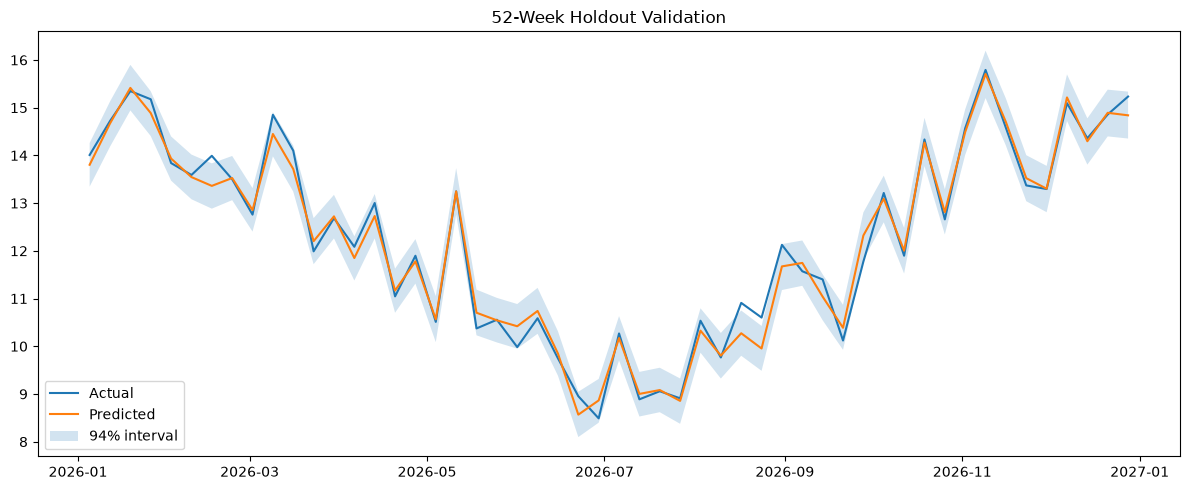

In [85]:
lower = y_pred.quantile(0.03, dim="sample").values
upper = y_pred.quantile(0.97, dim="sample").values

plt.figure(figsize=(12, 5))

plt.plot(test[DATE], y_test, label="Actual")
plt.plot(test[DATE], pred_mean, label="Predicted")
plt.fill_between(test[DATE], lower, upper, alpha=0.2, label="94% interval")

plt.title("52-Week Holdout Validation")
plt.legend()
plt.tight_layout()
plt.show()

,Spend Share,Contribution Share
Google Search,0.064,0.247
DV360,0.100,0.095
Facebook,0.060,0.217
AMS,0.050,0.204
TV,0.386,0.016
VOD,0.086,0.093
OOH,0.206,0.006
Radio,0.047,0.122


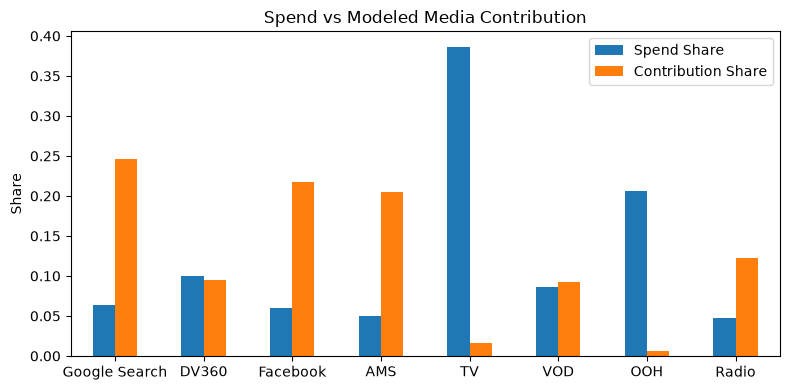

In [86]:
contrib = mmm.idata["posterior"]["channel_contribution_original_scale"]

total_contrib = (
    contrib
    .sum("date")
    .mean(("chain", "draw"))
    .to_series()
)

spend = train[CHANNELS].sum()

shares = pd.DataFrame({
    "Spend Share": spend / spend.sum(),
    "Contribution Share": total_contrib / total_contrib.sum(),
})

display(shares.round(3))

shares.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Share")
plt.title("Spend vs Modeled Media Contribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
roas = mmm.incrementality.contribution_over_spend(
    frequency="all_time"
)

roas_dollar = (
    roas.median(dim=("chain", "draw"))
    * ROAS_SCALE
)

roas_summary = roas_dollar.to_series().sort_values(ascending=False)

display(
    roas_summary.to_frame("ROAS").round(2)
)

,ROAS
channel,
AMS,22.91
Google Search,21.74
Facebook,20.24
Radio,14.49
VOD,6.07
DV360,5.31
TV,0.21
OOH,0.13


In [88]:
mroas = mmm.incrementality.marginal_contribution_over_spend(
    frequency="all_time",
    spend_increase_pct=0.01,
)

mroas_dollar = (
    mroas.median(dim=("chain", "draw"))
    * ROAS_SCALE
)

mroas_summary = mroas_dollar.to_series().sort_values(ascending=False)

display(
    mroas_summary.to_frame("mROAS").round(2)
)

,mROAS
channel,
AMS,21.42
Google Search,20.70
Facebook,19.99
Radio,13.82
VOD,5.83
DV360,5.03
TV,0.18
OOH,0.12


/opt/miniconda3/envs/walmart_mmm_312/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(
Sampling: []


Output()

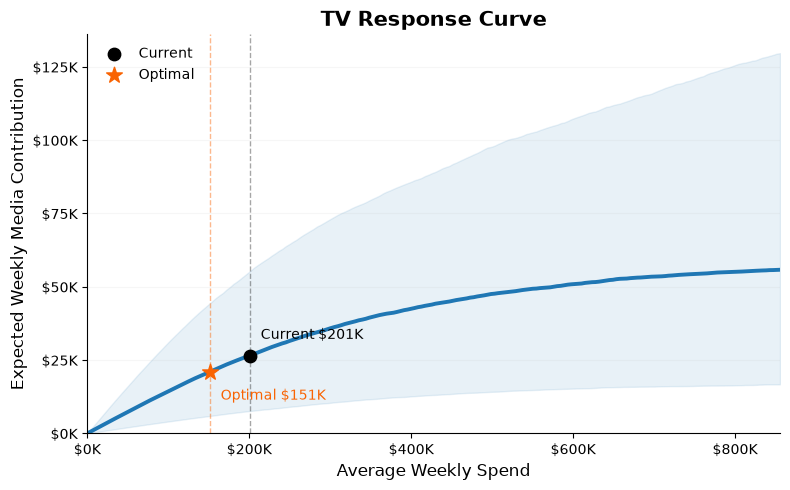

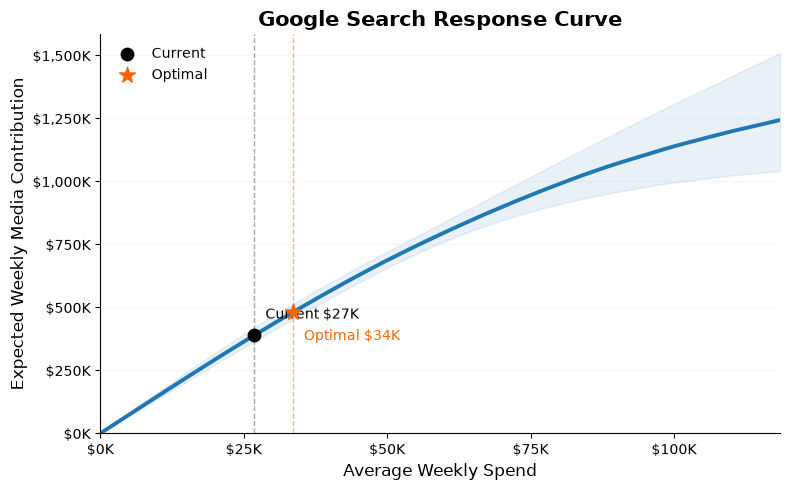

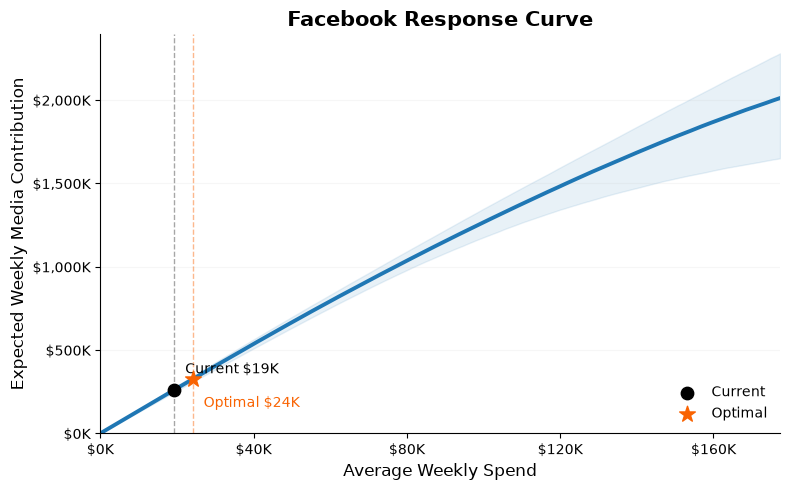

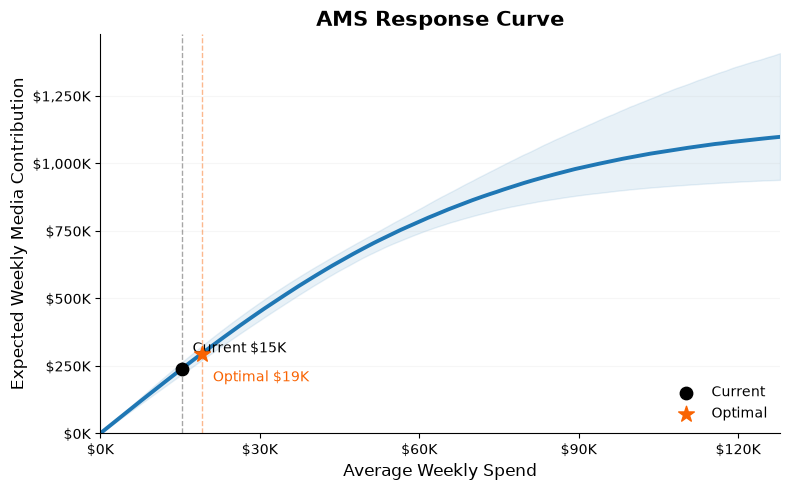

,Current Weekly Spend ($),Optimal Weekly Spend ($)
TV,"$200,500","$151,056"
Google Search,"$26,852","$33,564"
Facebook,"$19,259","$24,073"
AMS,"$15,283","$19,103"


In [89]:
# ============================================================
# Response curves: Current vs Optimal Spend
# Four separate channel plots
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)


# ------------------------------------------------------------
# 1. Load data and fitted model
# ------------------------------------------------------------

ROOT = next(
    p for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / "demo").exists()
)

DATE = "Weeks"

CHANNELS = [
    "Google Search",
    "DV360",
    "Facebook",
    "AMS",
    "TV",
    "VOD",
    "OOH",
    "Radio",
]

KEY_CHANNELS = [
    "TV",
    "Google Search",
    "Facebook",
    "AMS",
]

SPEND_UNIT = 10_000
REVENUE_UNIT = 250_000
HORIZON = 13

df = pd.read_csv(
    ROOT / "demo/data/mock_cgp_data.csv",
    parse_dates=[DATE],
)

train = df.iloc[:-52].copy()

mmm = MMM.load(
    ROOT / "demo/artifacts/mmm_demo_8ch.nc"
)


# ------------------------------------------------------------
# 2. Current 13-week budget
# ------------------------------------------------------------

current = (
    train
    .tail(HORIZON)[CHANNELS]
    .sum()
)

budget = current.sum()


# ------------------------------------------------------------
# 3. Re-run the same optimization as Notebook 03
# ------------------------------------------------------------

start_date = (
    train[DATE].max()
    + pd.Timedelta(weeks=1)
)

end_date = (
    start_date
    + pd.Timedelta(weeks=12)
)

optimizer = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=start_date,
    end_date=end_date,
)

bounds = xr.DataArray(
    np.column_stack([
        current.values * 0.75,
        current.values * 1.25,
    ]),
    dims=["channel", "bound"],
    coords={
        "channel": CHANNELS,
        "bound": ["lower", "upper"],
    },
)

optimal_allocation, result = optimizer.optimize_budget(
    budget=budget,
    budget_bounds=bounds,
)

optimal = optimal_allocation.to_series()


# ------------------------------------------------------------
# 4. Convert 13-week totals to average weekly spend
# ------------------------------------------------------------

current_weekly = current / HORIZON
optimal_weekly = optimal / HORIZON


# ------------------------------------------------------------
# 5. Sample posterior response curves
# ------------------------------------------------------------

rng = np.random.default_rng(20260920)

posterior_4ch = (
    mmm.idata.posterior[
        ["saturation_beta", "saturation_lam"]
    ]
    .sel(channel=KEY_CHANNELS)
)

response_curves = mmm.saturation.sample_curve(
    posterior_4ch,
    max_value=2.0,
    num_points=200,
    random_seed=rng,
)


# ------------------------------------------------------------
# 6. Convert response to original revenue scale
# ------------------------------------------------------------

target_scale = float(
    mmm.idata.constant_data[
        "target_scale"
    ].values
)

response_curves_original = (
    response_curves
    * target_scale
)


# ------------------------------------------------------------
# 7. Posterior summaries
# ------------------------------------------------------------

median_curve = (
    response_curves_original
    .median(dim=("chain", "draw"))
)

lower_curve = (
    response_curves_original
    .quantile(
        0.10,
        dim=("chain", "draw"),
    )
)

upper_curve = (
    response_curves_original
    .quantile(
        0.90,
        dim=("chain", "draw"),
    )
)

x_scaled = (
    response_curves
    .coords["x"]
    .values
)


# ------------------------------------------------------------
# 8. Get channel scaling
#
# x = 1 corresponds approximately to that channel's
# historical maximum weekly spend.
# ------------------------------------------------------------

if "channel_scale" in mmm.idata.constant_data:

    channel_scale = (
        mmm.idata.constant_data[
            "channel_scale"
        ]
        .sel(channel=KEY_CHANNELS)
    )

else:

    # Fallback if channel_scale is not stored
    channel_scale = xr.DataArray(
        train[KEY_CHANNELS]
        .max()
        .values,
        dims=["channel"],
        coords={
            "channel": KEY_CHANNELS
        },
    )


# ------------------------------------------------------------
# 9. Plot four separate response curves
# ------------------------------------------------------------

for channel in KEY_CHANNELS:

    scale = float(
        channel_scale
        .sel(channel=channel)
        .values
    )

    # Response-curve X axis -> actual weekly dollars
    x_dollars = (
        x_scaled
        * scale
        * SPEND_UNIT
    )

    y_median = (
        median_curve
        .sel(channel=channel)
        .values
    )

    y_lower = (
        lower_curve
        .sel(channel=channel)
        .values
    )

    y_upper = (
        upper_curve
        .sel(channel=channel)
        .values
    )


    # --------------------------------------------------------
    # Current and optimal weekly spend
    # --------------------------------------------------------

    current_spend_units = float(
        current_weekly[channel]
    )

    optimal_spend_units = float(
        optimal_weekly[channel]
    )

    current_spend_dollars = (
        current_spend_units
        * SPEND_UNIT
    )

    optimal_spend_dollars = (
        optimal_spend_units
        * SPEND_UNIT
    )


    # Convert actual spend back to response-curve x scale
    current_x = (
        current_spend_units
        / scale
    )

    optimal_x = (
        optimal_spend_units
        / scale
    )


    # Corresponding response on median curve
    current_y = np.interp(
        current_x,
        x_scaled,
        y_median,
    )

    optimal_y = np.interp(
        optimal_x,
        x_scaled,
        y_median,
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    line, = ax.plot(
        x_dollars,
        y_median,
        linewidth=2.8,
    )

    ax.fill_between(
        x_dollars,
        y_lower,
        y_upper,
        color=line.get_color(),
        alpha=0.10,
    )


    # Current
    ax.scatter(
        current_spend_dollars,
        current_y,
        s=80,
        color="black",
        zorder=5,
        label="Current",
    )

    ax.axvline(
        current_spend_dollars,
        linestyle="--",
        linewidth=1,
        color="black",
        alpha=0.35,
    )


    # Optimal
    ax.scatter(
        optimal_spend_dollars,
        optimal_y,
        s=140,
        marker="*",
        color="#F96302",
        zorder=6,
        label="Optimal",
    )

    ax.axvline(
        optimal_spend_dollars,
        linestyle="--",
        linewidth=1,
        color="#F96302",
        alpha=0.45,
    )


    # --------------------------------------------------------
    # Point labels
    # --------------------------------------------------------

    ax.annotate(
        f"Current ${current_spend_dollars / 1000:,.0f}K",
        (
            current_spend_dollars,
            current_y,
        ),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=10,
    )

    ax.annotate(
        f"Optimal ${optimal_spend_dollars / 1000:,.0f}K",
        (
            optimal_spend_dollars,
            optimal_y,
        ),
        xytext=(8, -20),
        textcoords="offset points",
        fontsize=10,
        color="#F96302",
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xlim(
        0,
        x_dollars.max(),
    )

    ax.set_ylim(bottom=0)

    # Fewer X-axis labels
    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, _:
            f"${x / 1000:,.0f}K"
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda y, _:
            f"${y * REVENUE_UNIT / 1000:,.0f}K"
        )
    )

    ax.set_xlabel(
        "Average Weekly Spend",
        fontsize=12,
    )

    ax.set_ylabel(
        "Expected Weekly Media Contribution",
        fontsize=12,
    )

    ax.set_title(
        f"{channel} Response Curve",
        fontsize=15,
        fontweight="bold",
    )

    ax.legend(
        frameon=False,
        fontsize=10,
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.10,
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Quick check
# ------------------------------------------------------------

check = pd.DataFrame({
    "Current Weekly Spend ($)":
        current_weekly[KEY_CHANNELS] * SPEND_UNIT,

    "Optimal Weekly Spend ($)":
        optimal_weekly[KEY_CHANNELS] * SPEND_UNIT,
})

display(
    check.style.format(
        "${:,.0f}"
    )
)